
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">


1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ==========================================
# 0. PARÁMETROS DEL PROBLEMA
# ==========================================
a = 20.0  # mm (largo en x)
b = 10.0  # mm (ancho en y)
D = 84.0  # mm^2/s (difusividad térmica del aluminio)

# Malla espacial
dx = 0.2  # mm
dy = 0.2  # mm
nx = int(a / dx) + 1
ny = int(b / dy) + 1

x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y)

# Condición en el borde superior f(x)
f_x = 100.0 * np.sin(3.0 * np.pi * x / a)

# ==========================================
# 1. SOLUCIÓN ESTÁTICA NUMÉRICA (FDM)
# ==========================================
# Inicializamos matriz de temperaturas
u_static = np.zeros((ny, nx))

# Condiciones de Frontera:
u_static[-1, :] = f_x  # Borde superior (y = b)
u_static[0, :]  = 0.0  # Borde inferior (y = 0)
u_static[:, 0]  = 0.0  # Borde izquierdo (x = 0)
u_static[:, -1] = 0.0  # Borde derecho (x = a)

# Solver iterativo de Laplace (Método de Relajación Gauss-Seidel vectorizado)
tol = 1e-6
error = 1.0
max_iter = 50000
iter_count = 0

while error > tol and iter_count < max_iter:
    u_old = u_static.copy()
    
    # Diferencias finitas para la ecuación de Laplace: u_ij = 0.25 * (u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1})
    u_static[1:-1, 1:-1] = 0.25 * (
        u_old[2:, 1:-1] + u_old[:-2, 1:-1] + 
        u_old[1:-1, 2:] + u_old[1:-1, :-2]
    )
    
    # Mantener condiciones de frontera fijas
    u_static[-1, :] = f_x
    u_static[0, :]  = 0.0
    u_static[:, 0]  = 0.0
    u_static[:, -1] = 0.0
    
    error = np.max(np.abs(u_static - u_old))
    iter_count += 1

print(f"Solución estática convergida en {iter_count} iteraciones.")


Solución estática convergida en 3442 iteraciones.


2. Compare the *static solution* with the analytical one.

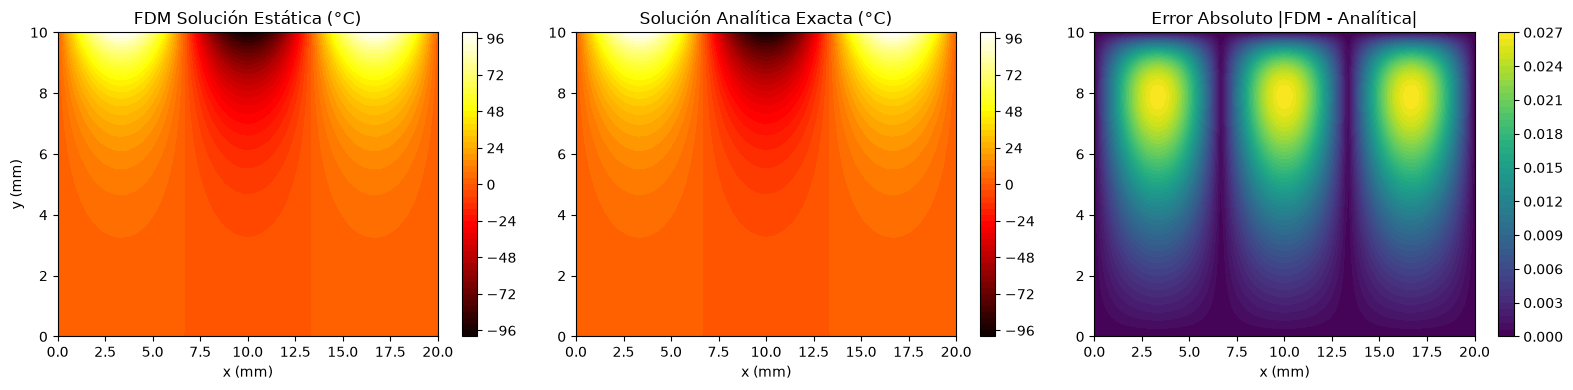

Error absoluto máximo: 2.6876e-02 °C


In [2]:
# 2. SOLUCIÓN ANALÍTICA Y COMPARACIÓN
# ==========================================
# Solución exacta por separación de variables
u_exact = 100.0 * np.sin(3.0 * np.pi * X / a) * (np.sinh(3.0 * np.pi * Y / a) / np.sinh(3.0 * np.pi * b / a))

# Graficación de la comparación
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

c1 = ax[0].contourf(X, Y, u_static, 50, cmap='hot')
ax[0].set_title('FDM Solución Estática (°C)')
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel('y (mm)')
fig.colorbar(c1, ax=ax[0])

c2 = ax[1].contourf(X, Y, u_exact, 50, cmap='hot')
ax[1].set_title('Solución Analítica Exacta (°C)')
ax[1].set_xlabel('x (mm)')
fig.colorbar(c2, ax=ax[1])

error_map = np.abs(u_static - u_exact)
c3 = ax[2].contourf(X, Y, error_map, 50, cmap='viridis')
ax[2].set_title('Error Absoluto |FDM - Analítica|')
ax[2].set_xlabel('x (mm)')
fig.colorbar(c3, ax=ax[2])

plt.tight_layout()
plt.show()

print(f"Error absoluto máximo: {np.max(error_map):.4e} °C")


3. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.


In [3]:
# 3. DIFUSIÓN EN EL TIEMPO (FDM 2D)
# ==========================================
# Criterio de estabilidad 2D: dt <= dx^2 * dy^2 / (2 * D * (dx^2 + dy^2))
dx2 = dx**2
dt = 0.2 * (dx2 / (4.0 * D))  # Paso de tiempo seguro (dt ~ 0.000119 s)

t_final = 0.3  # tiempo total de simulación en segundos
n_steps = int(t_final / dt)

# Estado inicial (t = 0): Placa inicialmente a 0°C con frontera fija f(x) arriba
u_time = np.zeros((ny, nx))
u_time[-1, :] = f_x

# Almacenar historia para animación
frames_step = max(1, n_steps // 100)
history = [u_time.copy()]
times = [0.0]

for k in range(1, n_steps + 1):
    u0 = u_time.copy()
    
    # Esquema numérico vectorizado 2D
    u_time[1:-1, 1:-1] = u0[1:-1, 1:-1] + D * dt * (
        (u0[2:, 1:-1] + u0[:-2, 1:-1] - 2.0 * u0[1:-1, 1:-1]) / dx2 +
        (u0[1:-1, 2:] + u0[1:-1, :-2] - 2.0 * u0[1:-1, 1:-1]) / dx2
    )
    
    # Reaplicar Dirichlet BCs
    u_time[-1, :] = f_x
    u_time[0, :]  = 0.0
    u_time[:, 0]  = 0.0
    u_time[:, -1] = 0.0
    
    if k % frames_step == 0:
        history.append(u_time.copy())
        times.append(k * dt)


3. Do a gif for the temperature in time (bonus!)

In [4]:
# 4. GENERAR ANIMACIÓN (BONUS - GIF)
# ==========================================
fig_anim, ax_anim = plt.subplots(figsize=(7, 4))
contour = ax_anim.contourf(X, Y, history[0], 50, cmap='hot', vmin=-100, vmax=100)
cbar = fig_anim.colorbar(contour, ax=ax_anim)
cbar.set_label('Temperatura (°C)')
ax_anim.set_xlabel('x (mm)')
ax_anim.set_ylabel('y (mm)')

def update(frame):
    ax_anim.clear()
    c = ax_anim.contourf(X, Y, history[frame], 50, cmap='hot', vmin=-100, vmax=100)
    ax_anim.set_title(f'Evolución Térmica 2D - t = {times[frame]*1000:.1f} ms')
    ax_anim.set_xlabel('x (mm)')
    ax_anim.set_ylabel('y (mm)')
    return c

anim = FuncAnimation(fig_anim, update, frames=len(history), interval=50, blit=False)
anim.save('difusion_calor_2D.gif', writer='pillow', fps=20)
plt.close()

print("¡GIF guardado exitosamente como 'difusion_calor_2D.gif'!")

¡GIF guardado exitosamente como 'difusion_calor_2D.gif'!
